## Frame the problem

Ask below questions to understand the actual need. Based on that we can build the model - compromising on unimportant things while getting more accuracy on important things.

 1. How the output will be used?
    The model's output will be fed to another machine learning system along with many other signals. This downstream system will determine whether it is worth investing in a given area.
 2. What is the current solution?
    The median price is fetched manually by a team of people working on the ground. When a reasonable median price is not possible to gather on the field, a complex rule is employed to estimate the median housing price. This is costly and time-consuming, and their estimates are not great. In case where they manage to find out the actual median housing price, they often realize that their estimates were off by more than 30%.

 * This is a supervised learning task
 * Since the model is asked to predict a value, it is a regression task - It is a *multiple regression* problem, since the system will use multiple features to make a prediction
 * Univariate (not multivariate) regression as we're predicting a single value per district
 


## Hypothesis
*hypothesis* is aka prediction function. `h` is the hypothesis in the below equation.

$$
 ŷ^{(i)} = h(x^{(i)})
$$

ŷ is the predicted value for the i-th training example. The prediction error will be $ y^{(i)} - ŷ^{(i)} $

## Cost / utility function

 * RMSE = Root Mean Squared Error
 $$
    RMSE = \sqrt{ \frac{1}{m} \sum_{i=1}^{m} (y^{(i)} - ŷ^{(i)})^2 }
 $$

 * MAE = Mean Absolute Error
    $$
        MAE = \frac{1}{m} \sum_{i=1}^{m} |y^{(i)} - ŷ^{(i)}|
    $$

In both equations,
 - $y^{(i)}$ is the actual vector,
 - $ŷ^{(i)}$ is the predicted vector,

## Cost functions in Norms

 * RMSE uses L2 norm. It is know as *Euclidean norm* - $l_2$ or $||.||_2$. Because it measures the shortest distance between two points in a plane.
 * MAE uses L1 norm. it is known as *Manhattan norm* or *Taxicab norm* - $l_1$ or $||.||_1$. Because it measures the actual distance between two points in a city.

Generally,

$$
    L_p = \left( \sum_{i=1}^{m} |y^{(i)} - ŷ^{(i)}|^p \right)^{\frac{1}{p}}
$$

Where p is the order of the norm or the norm index.
The higher the norm index, the more it focuses on large values and neglects small ones. It is more sensitive to outliers. Higher order of norm should be used when outliers are exponentially rare.

## Load the dataset

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    csv_path = Path("datasets/housing/housing.csv")
    if not csv_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")

    return pd.read_csv(csv_path)

housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Understand the dataset

In [2]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


 * Total number of attributes = 10
 * Total number of records = 20640
 * But `total_bedrooms` have only 20433 non-null values. So, it has some missing values.
 * `ocean_proximity` is a categorical attribute. It has text values. Others are numerical attributes. What is there in `ocean_proximity`?

In [3]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [4]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**More than seeing as a number, visualizing as a diagram helps to understand better.**

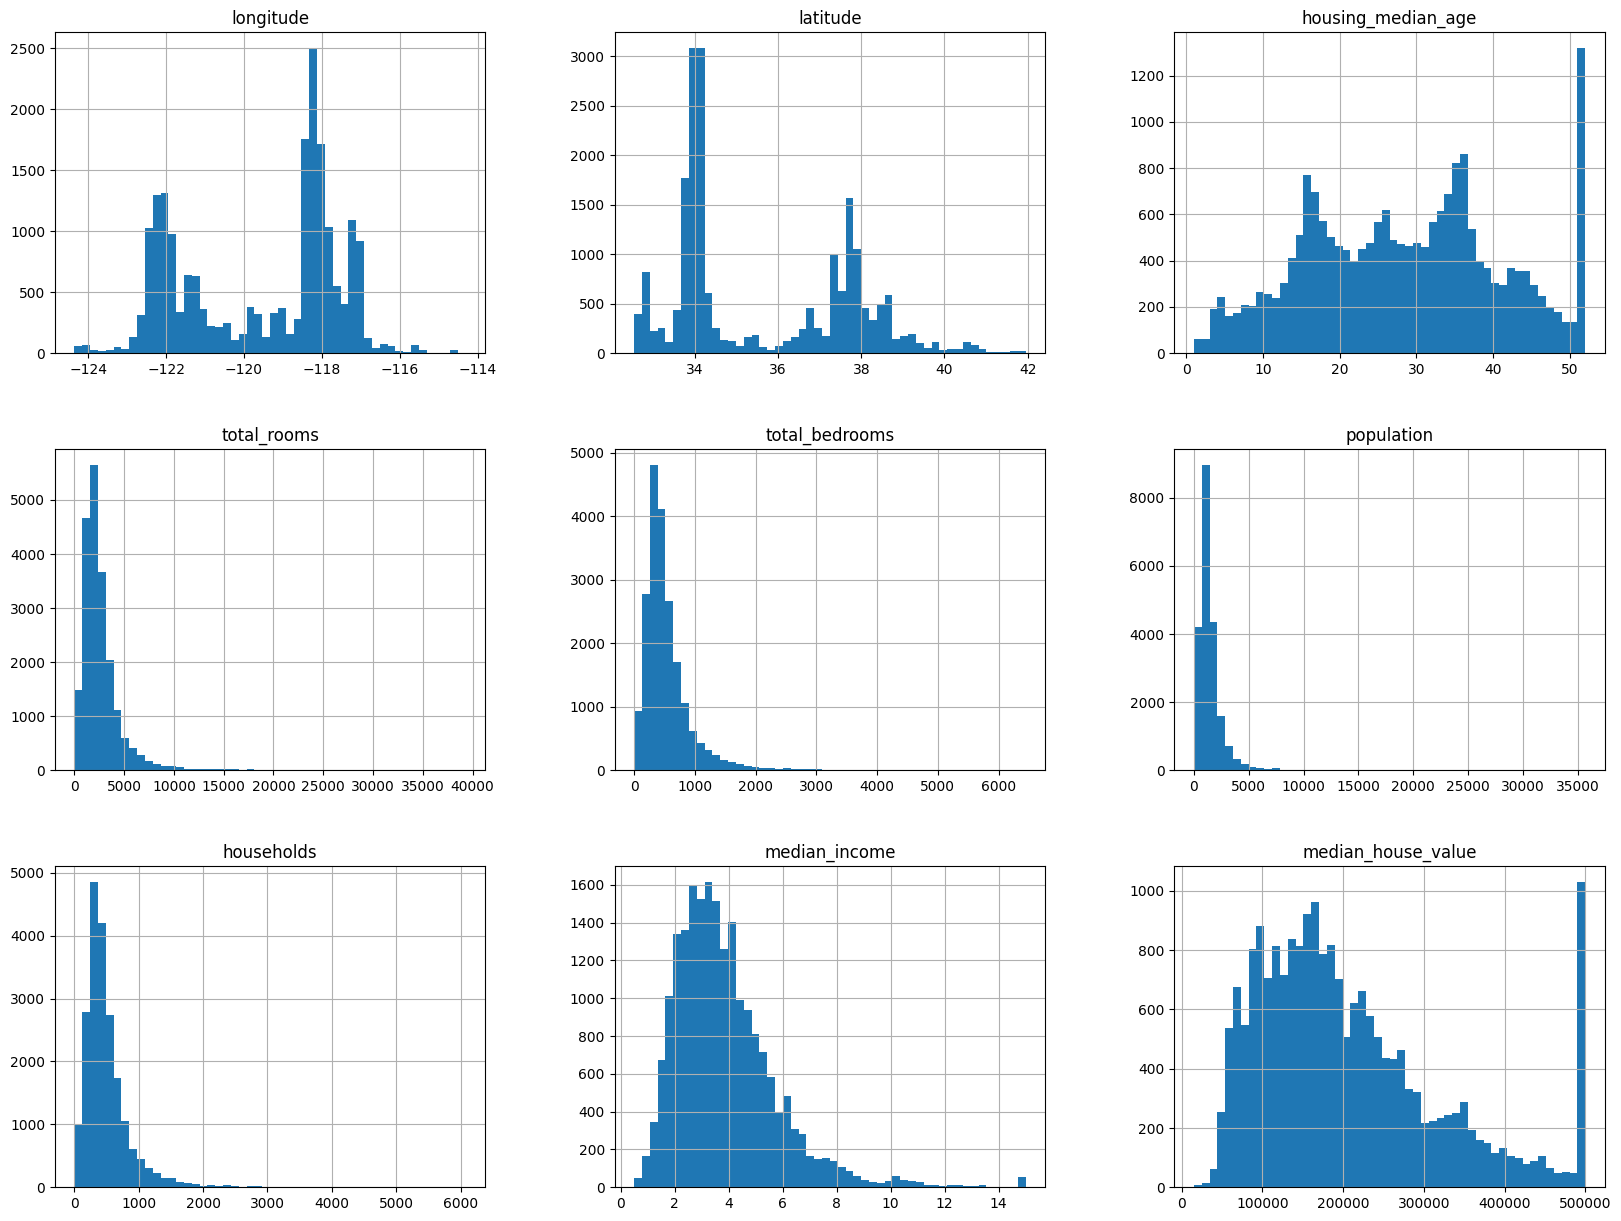

In [5]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

 * `median_income` is expressed in tens of thousands of dollars. So, 3.5 means $35,000. Also, it is capped at 15 (i.e., $150,000) to avoid the effect of extreme values.
 * `housing_median_age` is also capped at 52.
 * `median_house_value` is capped at $500,000. This is the target attribute. It is crucial. Because, the model will learn that the house_price will never go beyond $500,000. So, either we should collect proper value for those rows or we should remove those rows from both training and test sets. Otherwise, the model will never be able to predict beyond $500,000.
 * Attributes are in different scales. For example, `median_income` is in tens of thousands whereas `housing_median_age` is in years. So, feature scaling is required before feeding the data to the model.
 * Many histograms are *skewed right* or having a long right tail.

## Create a Test set

Creating a test-set even before selecting the model is good. Because, we'll be biased in selecting the test, if we see the data - **data snooping bias**. So, split test-set and then examine.

In [6]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    np.random.seed(12) # For reproducibility. Every time you run, you'll get the same result.
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = shuffle_and_split_data(housing, 0.2)

len(train_set), len(test_set)


(16512, 4128)

But if the dataset is updated, then the split will mix. The entries previously present in the test set may end up in the training set. It is not desired. Because, over multiple iterations, the model will see all the entries and overfit with each one of them. So, it will perform better on the test set, but poorly in real world.

So, the best solution is to split the data based on a unique identifier. As the `housing` dataset doesn't have any unique identifier, we can use the row index. But it is also not reliable. Because, if a new row is inserted at the top, all the indices will change. The other option is to build a unique identifier based on the row's attributes like longitude and latitude. But it is also not reliable. Because when doing so, we should make sure that some region always end-up in the test set. The split should be distributed uniformly across the whole dataset.

The same `shuffle_and_split_data` can be be achieved using `train_test_split` method of `sklearn.model_selection` module.

In [7]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

## Stratified Sampling

The test set should represent the actual population. For example if there are 48% male and 52% female population in the entire country, then the test set should also have the same ratio. Otherwise, the model will perform poorly in real world.

*Definition*: The population is divided into homogeneous subgroups called *strata*. The right number of instances are sampled from each stratum to guarantee that the test set is representative of the overall population.

In our case, we have an indirect stratification. The `median_income` attribute is an important predictor of `median_house_value`. Because, if higher income people staying nearby, they are likely to bet more for each house in their neighborhood. So, we can create an income category attribute based on `median_income` attribute.

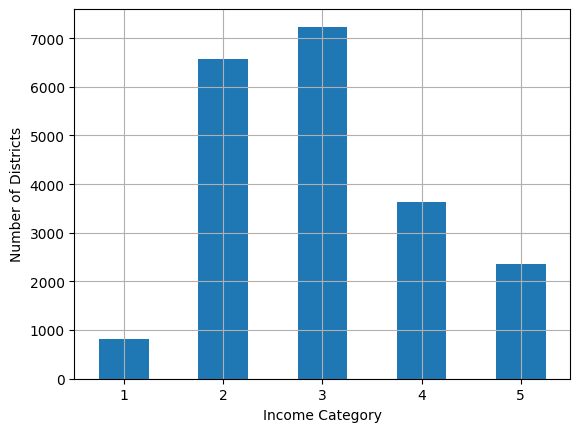

In [8]:
# Introduce a new column to the original housing DataFrame
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
                               labels=[1, 2, 3, 4, 5])

# Let's plot the distribution in a bar graph
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income Category")
plt.ylabel("Number of Districts")
plt.show()

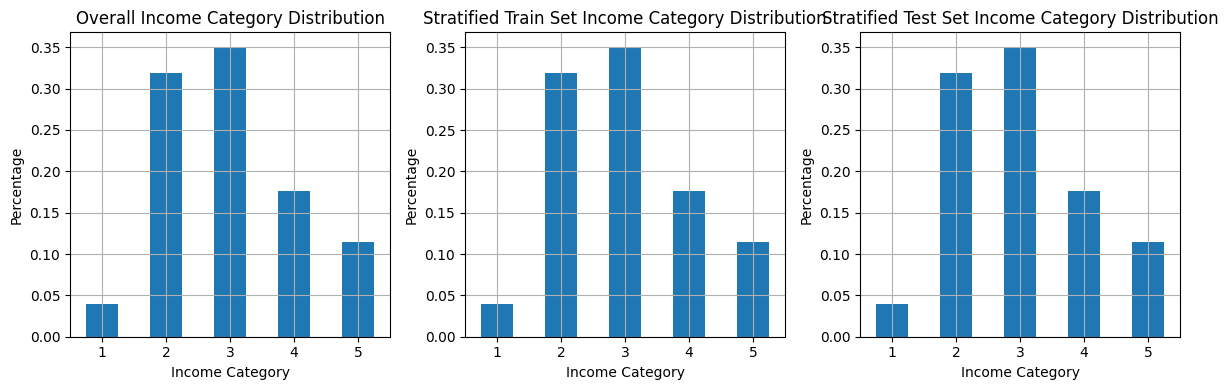

In [9]:
# Now, let's have a stratified sampling of the data based on `income_cat` attribute
from sklearn.model_selection import StratifiedShuffleSplit

# Using n_splits, we can specify how many re-shuffling & splitting iterations are needed.
# All the splits are different but with same stratification properties.
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    # scikit-learn returns the indices. We need to use .loc to get the actual rows
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# Let's plot the stratified training and test set to see whether the property holds
# Plot both of them side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

# plot income_cat vs income_cat_distribution for all data.
# x-axis should be income_cat and y-axis should be income_cat_distribution in percentage
# Use normalize=True to get the percentage. It normalizes the counts to sum between 0 and 1.
housing["income_cat"].value_counts(normalize=True).sort_index().plot.bar(ax=ax1, rot=0, grid=True)
ax1.set_title("Overall Income Category Distribution")
ax1.set_xlabel("Income Category")
ax1.set_ylabel("Percentage")

strat_train_set["income_cat"].value_counts(normalize=True).sort_index().plot.bar(ax=ax2, rot=0, grid=True)
ax2.set_title("Stratified Train Set Income Category Distribution")
ax2.set_xlabel("Income Category")
ax2.set_ylabel("Percentage")

strat_test_set["income_cat"].value_counts(normalize=True).sort_index().plot.bar(ax=ax3, rot=0, grid=True)
ax3.set_title("Stratified Test Set Income Category Distribution")
ax3.set_xlabel("Income Category")
ax3.set_ylabel("Percentage")

plt.tight_layout()
plt.show()

## Correlation

Correlation ranges between -1 and +1.

 * +1 indicates a perfect positive correlation. When one variable increases, the other variable also increases proportionally.
 * -1 indicates a perfect negative correlation. When one variable increases, the other variable decreases proportionally.
 * 0 indicates no correlation. Changes in one variable do not predict changes in the other variable.

In [10]:
housing = strat_train_set.copy()
housing.drop("income_cat", axis=1, inplace=True)
housing.drop("ocean_proximity", axis=1, inplace=True)

# housing.columns
## Correlation
housing.corr()["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

## scatter_matrix

Correlation shows only linear relationships. But there may be non-linear relationships too. So, plotting them relation in using `scatter_matrix` helps to identify such relationships. `scatter_matrix` plots all possible pairs in the given dataset. With 9 columns in our dataset, it will generate 81 plots. So, we can select only few important attributes to plot.

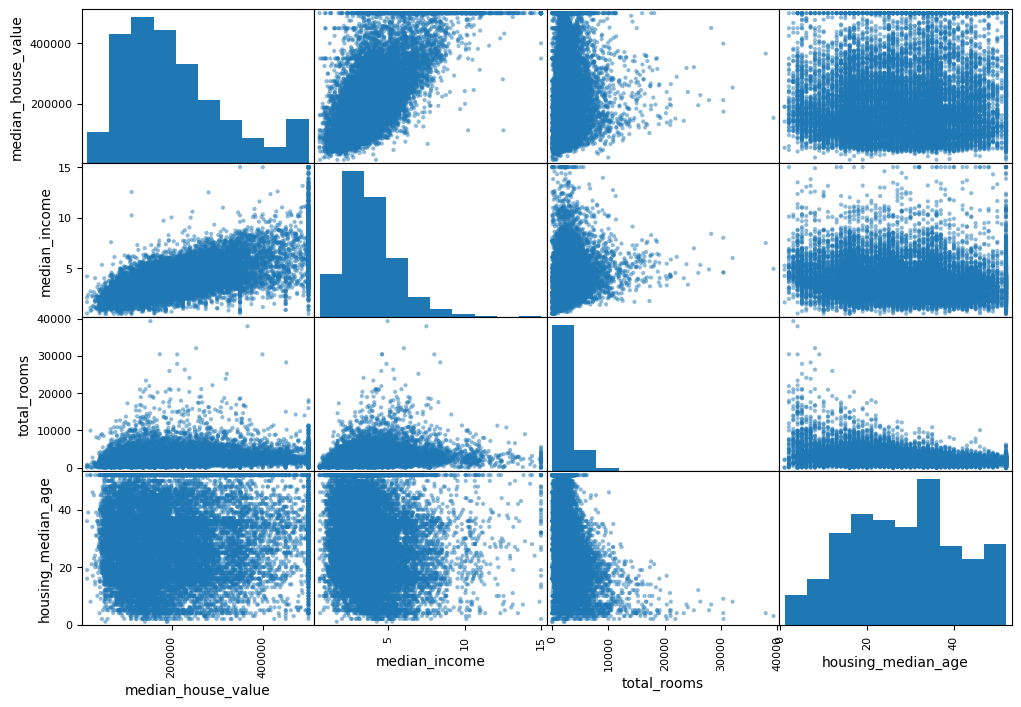

In [11]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

The correlation coefficient only measures linear correlations (“as x goes up, y generally goes up/down”). It may completely miss out on nonlinear relationships (e.g., “as x approaches 0, y generally goes up”). Figure 2-16 shows a variety of datasets along with their correlation coefficient. Note how all the plots of the bottom row have a correlation coefficient equal to 0, despite the fact that their axes are clearly not independent: these are examples of nonlinear relationships. Also, the second row shows examples where the correlation coefficient is equal to 1 or –1; notice that this has nothing to do with the slope. For example, your height in inches has a correlation coefficient of 1 with your height in feet or in nanometers.

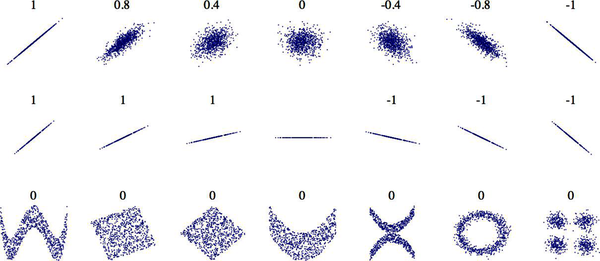

# Prepare the data for ML algorithms

## Fill missing values

It is called as *imputation*. There are multiple ways to fill the missing values.

 * Option 1: Remove the districts with missing values. But it may remove many useful data. `housing.dropna(subset=["total_bedrooms"], inplace=True)`.
 * Option 2: Remove the whole `total_bedrooms` attribute. But it is an important attribute. `housing.drop("total_bedrooms", axis=1, inplace=True)`.
 * Option 3: Set the missing values to some value (like 0, mean, median, etc.,). But it may skew the data. `housing["total_bedrooms"].fillna(housing["total_bedrooms"].median(), inplace=True)`.
 * Option 4: Set the missing values to some value (like mean, median, etc.,) based on other attributes. For example, we can set the missing `total_bedrooms` based on `total_rooms` and `population` attributes. But it is complex to implement.
 
 Scikit-Learn provides `SimpleImputer` class to handle such missing values. It provides various strategies like mean, median, most_frequent, constant to fill the missing values. Here, we'll use median strategy.

 `SimpleImputer` works like a model. It learns the parameters from the training data using `fit()` method and then applies those parameters to fill the missing values using `transform()` method. Or both can be done together using `fit_transform()` method.

In [12]:
# Imputer works only for numerical attributes. So, we need to drop the text attribute `ocean_proximity` first.
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median") # strategy = "mean", "median", "most_frequent", "constant & fill_value". Last two will work for non-numerical too.
housing = strat_train_set.copy()
housing_num = housing.drop("ocean_proximity", axis=1)
imputer.fit(housing_num)

print(imputer.statistics_)

X = imputer.transform(housing_num) # Returns a numpy array or sparse matrix. No column or row labels.
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
housing_tr.head()

[-1.1851e+02  3.4260e+01  2.9000e+01  2.1250e+03  4.3400e+02  1.1670e+03
  4.0800e+02  3.5385e+00  1.7920e+05  3.0000e+00]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,2.0
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,5.0
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,2.0
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,2.0
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,3.0


There are also more powerful imputers available in the sklearn.impute package (both for numerical features only):

KNNImputer replaces each missing value with the mean of the k-nearest neighbors’ values for that feature. The distance is based on all the available features.

IterativeImputer trains a regression model per feature to predict the missing values based on all the other available features. It then trains the model again on the updated data, and repeats the process several times, improving the models and the replacement values at each iteration.

## Handling text and categorical attributes

In our case the `ocean_proximity` is a categorical textual attribute. ML algorithms don't prefer text. So, it is better to convert it into a numerical representation. We've `OrdinalEncoder` in `sklearn.preprocessing` module to convert categorical text attributes to ordinal numerical attributes. It converts each unique text value to an integer value.

In [13]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing[["ocean_proximity"]])
housing_cat_encoded[:10]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.],
       [0.],
       [0.]])

Problem with this method is, the ML algorithm will treat nearby number as more related over far distanced numbers. So, `NEAR BAY` and `<1H OCEAN` should be kept in adjacent numbers. It may not be possible every time when the categorical attributes are equally distant.

This is the case, we'll use *OneHotEncoder* from `sklearn.preprocessing` module. It creates a binary array like representation. If there are N unique categories, it creates N binary attributes. Only one attribute will be hot (1) at a time, others will be cold (0). Hence the name *One Hot Encoding*.

In [14]:
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder()
housing_cat_1hot = onehot_encoder.fit_transform(housing[["ocean_proximity"]])
housing_cat_1hot[0:10].toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

This `onehot_encoder` will remember the column values. So, when new data is sent to `transform`, it will use the same mapping. If the newly provided data is with an unknown value, it will raise an error.

To avoid this, we can set the parameter `handle_unknown='ignore'` while creating the `OneHotEncoder` object. In that case, it will create all zero array for unknown values.

In [15]:
print(onehot_encoder.feature_names_in_)
print(onehot_encoder.categories_)

['ocean_proximity']
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


## Feature Scaling and Transformation

Most of the ML algorithms perform better when all the input attributes are on the same scale. For example, number of rooms range from 5 to 39,000. But the median income ranges only from 0 to 15. So, the model will be biased towards number of rooms attribute. To avoid this, we should bring all the attributes to the same scale.

RISK: The scaling will happen based on the min and max in the training dataset. But if the actual data fall beyond the range, it will perform poorly.

### Normalization
 * Also known as *Min-Max Scaling*. It scales all the values between 0 and 1.
 * `MinMaxScaler` class in `sklearn.preprocessing` module to perform normalization. It has `feature_range` hyperparameter.
 * It subtracts the min value from each attribute and then divides it by the range (max-min).

 ```python
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
 ```

### Standardization
 * It scales the data such that the resulting distribution has a mean value 0 and standard deviation 1.
 * `StandardScaler` class in `sklearn.preprocessing` module to perform standardization. 
 * It subtracts the mean value from each attribute and then divides it by the standard deviation.

*It doesn't get affected by outliers as much as normalization. For example, the `median-income` in the training set has an outlier 100 and the rest are between 0 and 15, the normalization will fit 100 to 1 and rest all will fall between 0 and 0.15. But in standardization, the outlier will be captured still as an outlier as we use standard deviation.*

 ```python
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
 ```


### Power law distribution

 * When a feature has long tail, reduce it using power transformation. Simply take a square root. Or raise it to the power between 0 and 1 (0.33 is cube-root).
 * When there is a really long tail, use log transformation.

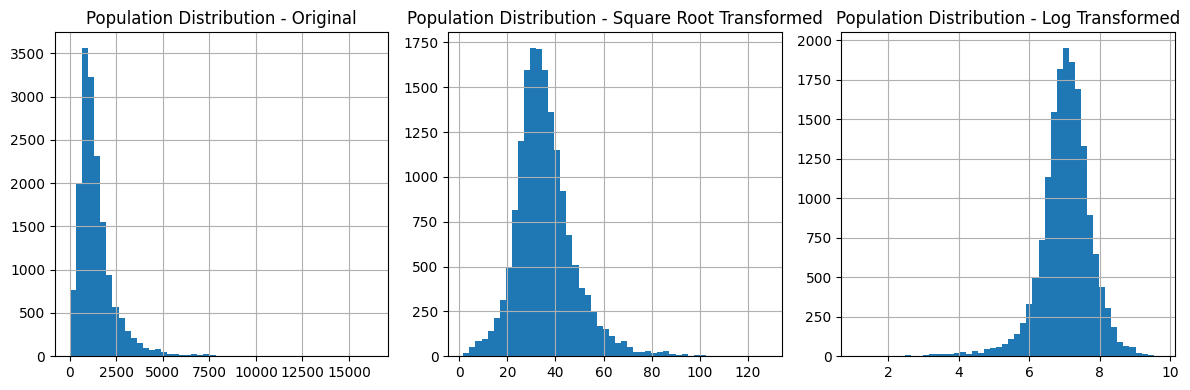

In [16]:
housing = strat_train_set.copy()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

housing['population'].hist(bins=50, ax=ax1)
ax1.set_title("Population Distribution - Original")

housing['population'].apply(lambda x: np.sqrt(x)).hist(bins=50, ax=ax2)
ax2.set_title("Population Distribution - Square Root Transformed") # slightly right skewed

housing['population'].apply(lambda x: np.log(x)).hist(bins=50, ax=ax3)
ax3.set_title("Population Distribution - Log Transformed") # slightly left skewed

# Always bell curve is better for ML algorithms
plt.tight_layout()
plt.show()


### Bucketizing

Another simple approach to handle long tail distribution is to *bucketize* the feature. For example, if an attribute ranges from 1 to 1000, we can create 10 buckets - 1-100, 101-200, ..., 901-1000. Then we can replace the actual value with the bucket number (1 to 10). This way, we can reduce the effect of extreme values.

### Handling multimodel distribution features

When an input distribution has more than one peak, it is called as multimodel. e.g. `housing_median_age` attribute in our dataset. We can bucketize them based on peaks and use an `OneHotEncoder` to represent them.

Another approach is to represent similarity between housing-age and a particular mode. Like create two different features with respect to the two peaks. For this we use `RBF - radical basis function` kernels. **RBF decays exponentially as we move away from the center.**

Gaussian RBF for housing age around 35 is exp(–γ(x – 35)²). Here γ (gamma) determines how fast the RBF decays. Similarly, for housing age around 15, it is exp(–γ(x – 15)²).

In [17]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

## Inverse transform

We have scaled and transformed only the input data. We need to do the same for the output data too. For example, if the output data has a long tail distribution, we may have applied log transformation. So, after getting the predictions from the model (which is log of expected value), we need to apply exponential for that. Scikit-Learn helps here with `inverse_transform()` function to get the actual value.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

target_scalar = StandardScaler()
housing_labels = strat_train_set["median_house_value"].copy()
housing_labels_scaled = target_scalar.fit_transform(housing_labels.to_frame())

model = LinearRegression()
housing = strat_train_set.copy()
model.fit(housing[["median_income"]], housing_labels_scaled)

test_housing = strat_test_set.copy()
scaled_predictions = model.predict(test_housing[["median_income"]].iloc[:5])
predictions = target_scalar.inverse_transform(scaled_predictions)
print("Predictions:", predictions.flatten())
print("Labels:", test_housing["median_house_value"].iloc[:5].values)

Predictions: [368521.24764991 238429.42911631 215831.39858602 217266.32737202
 195142.41073886]
Labels: [397700. 202900. 310000. 314300. 187500.]


The same can be achieved by `TransformedTargetRegressor`

```python
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

model = TransformedTargetRegressor(
    regressor=LinearRegression(),
    transformer=StandardScaler()
)
```

`FunctionTransformer` class is very useful to create custom transformers. Some examples...

```python
from sklearn.preprocessing import FunctionTransformer
```

**Hyperparameters**
 * func: callable, default=None
    The function to be applied to the data. If None, the identity function is used.
 * inverse_func: callable, default=None
    The inverse function to be applied to the transformed data. If None, the identity function is used.
 * kw_args: dict, default=None
    Additional keyword arguments to pass to func.

In [19]:
import sklearn

sklearn.set_config(display='diagram')

## Train and Test the full data

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer, make_column_selector

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, input_features=None):
        return [f"cluster_simil_{i}" for i in range(self.n_clusters)]

housing = strat_train_set.copy()

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler() # subtract mean and divide by std deviation
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer(
    [
        ("bedrooms_against_total_rooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object))
    ],
    remainder=default_num_pipeline
)

housing_prepared = preprocessing.fit_transform(housing)
print(housing_prepared.shape)
preprocessing.get_feature_names_out()


(16512, 26)


array(['bedrooms_against_total_rooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__cluster_simil_0',
       'geo__cluster_simil_1', 'geo__cluster_simil_2',
       'geo__cluster_simil_3', 'geo__cluster_simil_4',
       'geo__cluster_simil_5', 'geo__cluster_simil_6',
       'geo__cluster_simil_7', 'geo__cluster_simil_8',
       'geo__cluster_simil_9', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__median_house_value',
       'remainder__income_cat'], dtype=object)

In [ ]:
housing = strat_train_set.copy()
housing_labels = housing["median_house_value"].copy()
housing.drop("median_house_value", axis=1, inplace=True)

housing_test = strat_test_set.copy()
housing_test_labels = housing_test["median_house_value"].copy()
housing_test.drop("median_house_value", axis=1, inplace=True)

Prediction:  [348600. 280800. 358800. 287100. 271100.]
    Labels:  [397700. 202900. 310000. 314300. 187500.]
RMSE: 75148.04384083638


### Predict with Linear Regression

In [32]:
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

housing_predictions = lin_reg.predict(housing)
print("Prediction: ", housing_predictions[:5].round(-2))
print("    Labels: ", housing_labels.values[:5])

rmse = root_mean_squared_error(housing_labels, housing_predictions)
print("RMSE:", rmse)

Prediction:  [250400. 395000. 127400.  87900. 332800.]
    Labels:  [458300. 483800. 101700.  96100. 361800.]
RMSE: 68300.8872739978


### Predict with Decision Tree Regressor

In [33]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

housing_predictions = tree_reg.predict(housing)
print("Prediction: ", housing_predictions[:5].round(-2))
print("    Labels: ", housing_labels.values[:5].round(-2))

rmse = root_mean_squared_error(housing_labels, housing_predictions)
print("RMSE:", rmse)


Prediction:  [458300. 483800. 101700.  96100. 361800.]
    Labels:  [458300. 483800. 101700.  96100. 361800.]
RMSE: 0.0


### cross validation

Decision tree tend to overfit the input data. So, when we test on already trained data, it gives the exact output. But if we run it against test-set, it will produce bad results similar to Linear Regression.

We can examine that using `cross_val_score`. It splits the dataset into 10 sets. Uses 9 folds for the training and test on the remaining one. Does it for 10 times with all 10 different sets and produces a mean.

In [34]:
from sklearn.model_selection import cross_val_score

tree_rmse_score = -cross_val_score(tree_reg, housing, housing_labels,
                                   scoring="neg_root_mean_squared_error",
                                   cv=10)

pd.Series(tree_rmse_score).describe()

count       10.000000
mean     66532.303625
std       1618.346537
min      64992.375699
25%      65378.062045
50%      65568.310266
75%      68216.420613
max      68843.320383
dtype: float64